# Восканян Юрий. КИ22-17/2б
### Практическая работа 1 - Программная реализация многослойного персептрона

In [56]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(X_train_full, y_train_full), (X_test_full, y_test_full) = keras.datasets.fashion_mnist.load_data()

classes_of_interest = [5, 8, 9]

def filter_classes(x, y, classes):
  mask = np.isin(y, classes)
  return x[mask], y[mask]

X_train, y_train = filter_classes(X_train_full, y_train_full, classes_of_interest)
X_test, y_test = filter_classes(X_test_full, y_test_full, classes_of_interest)

class_mapping = {cls: i for i, cls in enumerate(classes_of_interest)}

y_train = np.array([class_mapping[label] for label in y_train])
y_test = np.array([class_mapping[label] for label in y_test])


X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42)




In [58]:
list(X_train[5])

[array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0], dtype=uint8),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0], dtype=uint8),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0], dtype=uint8),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0], dtype=uint8),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0], dtype=uint8),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0], dtype=uint8),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0], dtype=uint8),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0], dtype=uint8),
 array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   0,   0,
       

## Нормализация данных. Приводим каждое значение в диапазон от 0.0 до 1.0

In [59]:
X_train = X_train / 255.0 
X_test = X_test / 255.0

# Построение многослойного персептрона

In [61]:
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

In [62]:
model.compile(optimizer='adam',              
              loss='sparse_categorical_crossentropy',  
              metrics=['accuracy'])  

In [63]:
history = model.fit(X_train, y_train,      
                    epochs=10,             
                    batch_size=32)  

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9401 - loss: 0.1696
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9851 - loss: 0.0431
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9885 - loss: 0.0331
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9919 - loss: 0.0259
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9908 - loss: 0.0253
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9947 - loss: 0.0150
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9957 - loss: 0.0122
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9967 - loss: 0.0114
Epoch 9/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9966 - loss: 0.0110
Epoch 10/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9972 - loss: 0.0064


In [64]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9831 - loss: 0.0736
Test accuracy: 0.9830


# Подбор гиперпараметров нейронной сети.

In [65]:
model_1 = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

In [66]:
model_2 = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='tanh'),
    layers.Dense(3, activation='softmax')
])

In [67]:
model_3 = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='tanh'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='tanh'),
    layers.Dense(3, activation='softmax')
])

In [68]:
model_1.compile(optimizer='adam',              
              loss='sparse_categorical_crossentropy',  
              metrics=['accuracy'])  

In [69]:
history = model_1.fit(X_train, y_train,      
                    epochs=10,             
                    batch_size=32,
              validation_data=(X_val_split, y_val_split))

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9260 - loss: 0.1981 - val_accuracy: 0.9808 - val_loss: 7.0376
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9849 - loss: 0.0455 - val_accuracy: 0.9772 - val_loss: 8.5874
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9889 - loss: 0.0323 - val_accuracy: 0.9728 - val_loss: 9.5343
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9918 - loss: 0.0249 - val_accuracy: 0.9722 - val_loss: 13.7192
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9929 - loss: 0.0238 - val_accuracy: 0.9794 - val_loss: 8.4577
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9953 - loss: 0.0126 - val_accuracy: 0.9358 - val_loss: 38.5244
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9932 - loss: 0.0183 - val_accuracy: 0.9758 - val_loss: 12.8578
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9960 - loss: 0.0114 - val_accuracy:

In [53]:
val_loss = min(history.history["val_loss"])
print(f'Model 1 loss: {val_loss:.4f}')

Model 1 loss: 0.8480


In [72]:
model_2.compile(optimizer='adam',              
              loss='sparse_categorical_crossentropy',  
              metrics=['accuracy'])  

In [74]:
val_loss = min(history.history["val_loss"])
print(f'Model 2 loss: {val_loss:.4f}')

Model 2 loss: 0.0168


In [75]:
model_3.compile(optimizer='adam',              
              loss='sparse_categorical_crossentropy',  
              metrics=['accuracy'])  

In [76]:
history = model_3.fit(X_train, y_train,      
                    epochs=10,             
                    batch_size=32,
              validation_data=(X_val_split, y_val_split)) 

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9438 - loss: 0.1565 - val_accuracy: 0.9106 - val_loss: 0.3234
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9809 - loss: 0.0573 - val_accuracy: 0.9253 - val_loss: 0.2890
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9893 - loss: 0.0342 - val_accuracy: 0.9281 - val_loss: 0.2742
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9899 - loss: 0.0317 - val_accuracy: 0.9533 - val_loss: 0.1692
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9881 - loss: 0.0339 - val_accuracy: 0.9592 - val_loss: 0.1463
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9929 - loss: 0.0213 - val_accuracy: 0.9858 - val_loss: 0.0498
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9934 - loss: 0.0177 - val_accuracy: 0.9706 - val_loss: 0.0842
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9956 - loss: 0.0127 - val_accuracy: 0.

In [77]:
val_loss = min(history.history["val_loss"])
print(f'Model 3 loss: {val_loss:.4f}')

Model 3 loss: 0.0365


In [78]:
test_loss, test_acc = model_2.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9902 - loss: 0.0513
Test accuracy: 0.9903
Test loss: 0.0433


# Лучше всех проявила себя модель 2. Будем использовать ее

In [79]:
optimizers = ['adam', 'sgd', 'rmsprop']
history_dict = {}

In [80]:
for optimizer in optimizers:
    model_2.compile(optimizer=optimizer,              
              loss='sparse_categorical_crossentropy',  
              metrics=['accuracy'])
    history = model_2.fit(X_train, y_train, epochs=10, batch_size=32,
                          validation_data=(X_val_split, y_val_split))
    history_dict[optimizer] = history.history

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9956 - loss: 0.0117 - val_accuracy: 0.9758 - val_loss: 0.0652
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9968 - loss: 0.0083 - val_accuracy: 0.9697 - val_loss: 0.1042
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9973 - loss: 0.0079 - val_accuracy: 0.9819 - val_loss: 0.0736
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9980 - loss: 0.0057 - val_accuracy: 0.9828 - val_loss: 0.0744
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9988 - loss: 0.0041 - val_accuracy: 0.9914 - val_loss: 0.0283
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9985 - loss: 0.0061 - val_accuracy: 0.9889 - val_loss: 0.0427
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9963 - loss: 0.0103 - val_accuracy: 0.9867 - val_loss: 0.0602
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9989 - loss: 0.0049 - val_accuracy: 0.

In [81]:
history_dict

{'adam': {'accuracy': [0.9952222108840942,
   0.9968888759613037,
   0.9976666569709778,
   0.9976111054420471,
   0.9976111054420471,
   0.9981111288070679,
   0.9972222447395325,
   0.9987778067588806,
   0.9976111054420471,
   0.9978888630867004],
  'loss': [0.01502725575119257,
   0.008218121714890003,
   0.006985793821513653,
   0.007141233887523413,
   0.007630321197211742,
   0.0061724139377474785,
   0.007717493921518326,
   0.005851055029779673,
   0.0073253861628472805,
   0.0061851441860198975],
  'val_accuracy': [0.9758333563804626,
   0.9697222113609314,
   0.9819444417953491,
   0.9827777743339539,
   0.9913889169692993,
   0.9888888597488403,
   0.9866666793823242,
   0.9877777695655823,
   0.9902777671813965,
   0.9872221946716309],
  'val_loss': [0.06522523611783981,
   0.10423146933317184,
   0.07361408323049545,
   0.074353888630867,
   0.028308043256402016,
   0.042654816061258316,
   0.06023984029889107,
   0.052073609083890915,
   0.02504943124949932,
   0.0513403

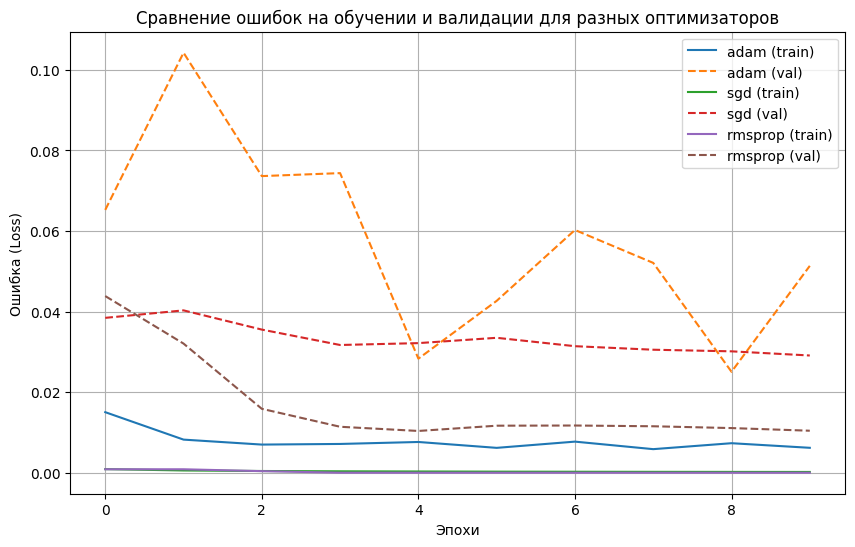

In [82]:
plt.figure(figsize=(10, 6))

for optimizer, history in history_dict.items():
    plt.plot(history['loss'], label=f'{optimizer} (train)')
    plt.plot(history['val_loss'], label=f'{optimizer} (val)', linestyle='--')

plt.title('Сравнение ошибок на обучении и валидации для разных оптимизаторов')
plt.xlabel('Эпохи')
plt.ylabel('Ошибка (Loss)')
plt.legend()
plt.grid(True)
plt.show()

# Batch-нормализация и Dropout

In [85]:
model_2 = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), 
    layers.Dropout(0.1),
    
    layers.Dense(64, activation='relu'),
    
    layers.BatchNormalization(),  
    layers.Dropout(0.1),
    
    layers.Dense(128, activation='tanh'),
    
    layers.BatchNormalization(),  
    layers.Dropout(0.1),
    
    layers.Dense(3, activation='softmax')
])

model_2.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
history = model_2.fit(X_train, y_train,
                      epochs=10,
                      batch_size=32,
                      validation_data=(X_val_split, y_val_split))


Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9346 - loss: 0.1818 - val_accuracy: 0.7647 - val_loss: 0.8773
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9743 - loss: 0.0753 - val_accuracy: 0.7581 - val_loss: 0.8558
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9776 - loss: 0.0689 - val_accuracy: 0.7586 - val_loss: 0.9282
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9799 - loss: 0.0593 - val_accuracy: 0.8708 - val_loss: 0.3604
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9807 - loss: 0.0514 - val_accuracy: 0.8233 - val_loss: 0.6893
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9865 - loss: 0.0397 - val_accuracy: 0.7839 - val_loss: 0.7342
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9874 - loss: 0.0388 - val_accuracy: 0.8556 - val_loss: 0.4721
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9899 - loss: 0.0337 - val_accuracy: 0.

In [84]:
model_2 = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), 
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    
    layers.BatchNormalization(),  
    layers.Dropout(0.3),
    
    layers.Dense(128, activation='tanh'),
    
    layers.BatchNormalization(),  
    layers.Dropout(0.3),
    
    layers.Dense(3, activation='softmax')
])

model_2.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
history = model_2.fit(X_train, y_train,
                      epochs=10,
                      batch_size=32,
                      validation_data=(X_val_split, y_val_split))


Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9138 - loss: 0.2457 - val_accuracy: 0.7222 - val_loss: 1.5360
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9630 - loss: 0.1104 - val_accuracy: 0.7217 - val_loss: 1.3823
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9718 - loss: 0.0908 - val_accuracy: 0.7633 - val_loss: 0.9602
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9730 - loss: 0.0784 - val_accuracy: 0.7406 - val_loss: 1.2759
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9788 - loss: 0.0698 - val_accuracy: 0.8839 - val_loss: 0.3456
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9768 - loss: 0.0695 - val_accuracy: 0.7992 - val_loss: 0.8716
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9764 - loss: 0.0698 - val_accuracy: 0.8211 - val_loss: 0.6351
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9800 - loss: 0.0624 - val_accuracy: 0.

In [86]:
model_2 = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), 
    layers.Dropout(0.5),
    
    layers.Dense(64, activation='relu'),
    
    layers.BatchNormalization(),  
    layers.Dropout(0.5),
    
    layers.Dense(128, activation='tanh'),
    
    layers.BatchNormalization(),  
    layers.Dropout(0.5),
    
    layers.Dense(3, activation='softmax')
])

model_2.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
history = model_2.fit(X_train, y_train,
                      epochs=10,
                      batch_size=32,
                      validation_data=(X_val_split, y_val_split))


Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8540 - loss: 0.4178 - val_accuracy: 0.7100 - val_loss: 1.4882
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9541 - loss: 0.1525 - val_accuracy: 0.8469 - val_loss: 0.6736
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9627 - loss: 0.1169 - val_accuracy: 0.8139 - val_loss: 1.0163
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9673 - loss: 0.0996 - val_accuracy: 0.8408 - val_loss: 0.7438
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9682 - loss: 0.1012 - val_accuracy: 0.8428 - val_loss: 0.7509
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9709 - loss: 0.1005 - val_accuracy: 0.8681 - val_loss: 0.5993
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9723 - loss: 0.0882 - val_accuracy: 0.8183 - val_loss: 0.8574
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9727 - loss: 0.0894 - val_accuracy: 0.

### Лучшее значение - 0.1

In [87]:
loss_values = history.history['loss']

In [88]:
loss_values

[0.2536875009536743,
 0.13873736560344696,
 0.11804067343473434,
 0.09901662170886993,
 0.0985490009188652,
 0.09382445365190506,
 0.08789100497961044,
 0.09568586945533752,
 0.08361143618822098,
 0.09676560759544373]